Connecting to the database...
Fetching data from view_scout_master...
Calculating correlation matrix...
Correlation matrix saved successfully at: 'images\feature_correlation_matrix.png'


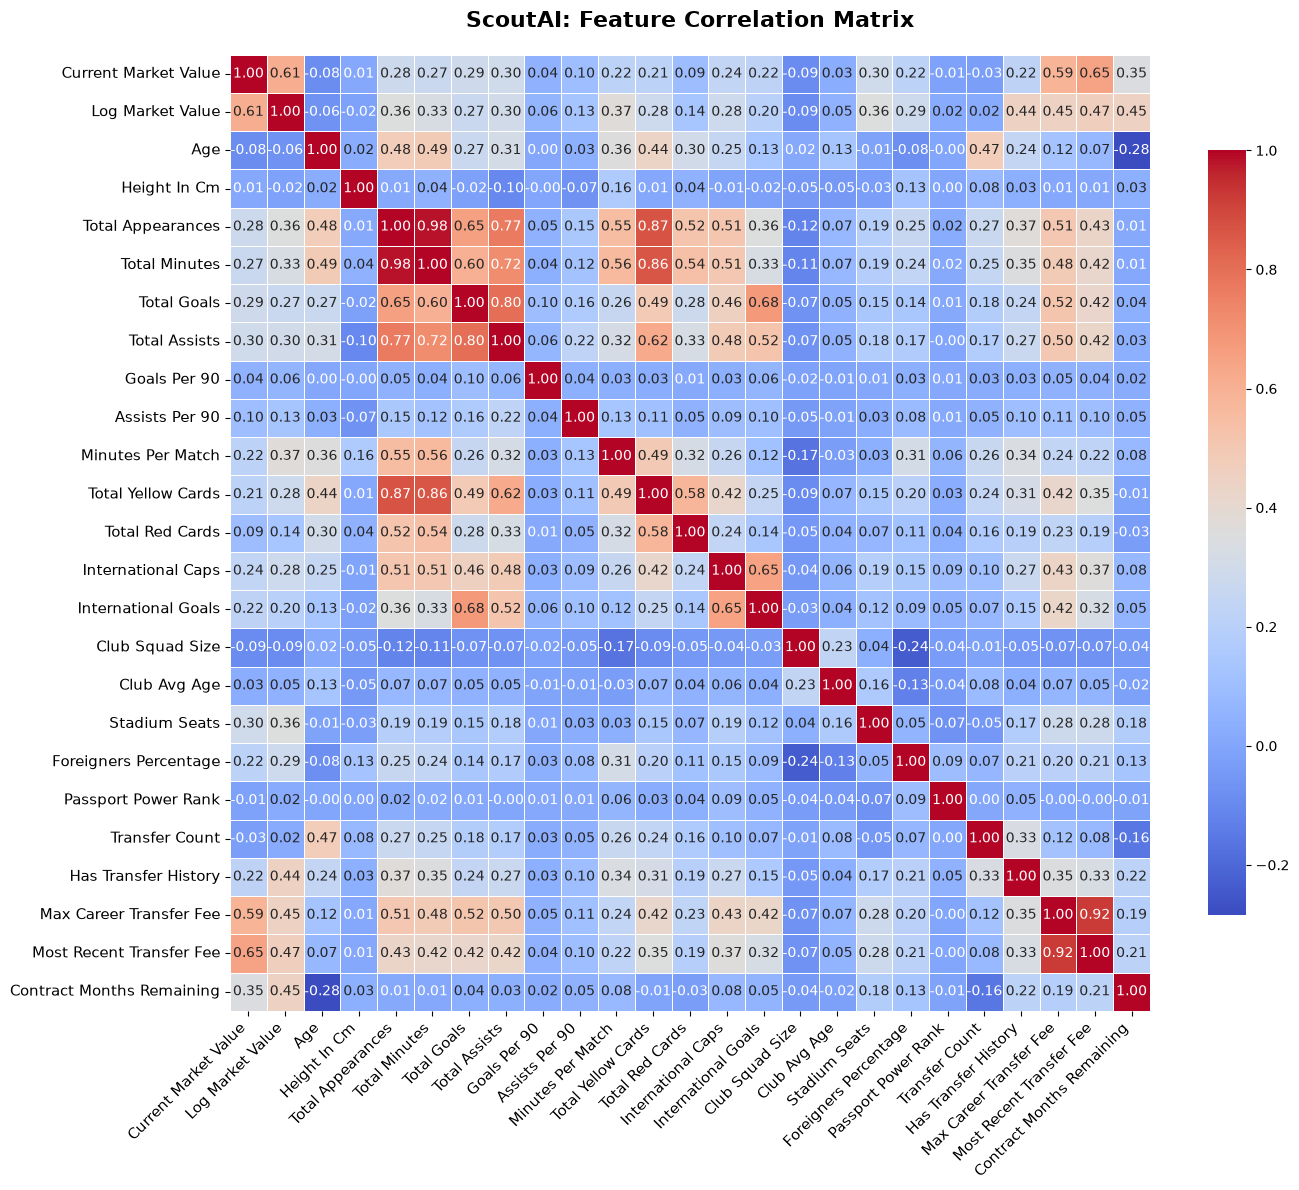


--- Correlation with Market Value ---
Log Market Value             1.000000
Current Market Value         0.609075
Most Recent Transfer Fee     0.465234
Max Career Transfer Fee      0.451377
Contract Months Remaining    0.449347
Has Transfer History         0.443278
Minutes Per Match            0.367959
Total Appearances            0.357304
Stadium Seats                0.355178
Total Minutes                0.332399
Total Assists                0.298999
Foreigners Percentage        0.286375
Total Yellow Cards           0.284152
International Caps           0.283809
Total Goals                  0.267594
International Goals          0.198449
Total Red Cards              0.135025
Assists Per 90               0.127405
Goals Per 90                 0.061487
Club Avg Age                 0.045451
Passport Power Rank          0.021102
Transfer Count               0.020196
Height In Cm                -0.015700
Age                         -0.064229
Club Squad Size             -0.089321
Name: Log M

In [3]:
import os
import pandas as pd
import sqlalchemy
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv, find_dotenv

# Locate and load the .env file dynamically
load_dotenv(find_dotenv())

# 1. Database Connection
db_url = os.getenv('DB_URL')
if not db_url:
    raise ValueError("[ERROR] DB_URL not found. Please ensure your .env file exists and is configured correctly.")

print("Connecting to the database...")
engine = sqlalchemy.create_engine(db_url)

# 2. Fetch Data
print("Fetching data from view_scout_master...")
query = "SELECT * FROM view_scout_master"
df = pd.read_sql(query, engine)

# 3. Select numeric columns and EXCLUDE irrelevant IDs
numeric_df = df.select_dtypes(include=['number'])
if 'player_id' in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=['player_id'])

# 4. Clean Feature Names for Professional Display
# Replaces underscores with spaces and capitalizes each word
clean_columns = {col: col.replace('_', ' ').title() for col in numeric_df.columns}
numeric_df = numeric_df.rename(columns=clean_columns)

# 5. Calculate the Correlation Matrix
print("Calculating correlation matrix...")
correlation_matrix = numeric_df.corr()

# 6. Visualization
plt.figure(figsize=(14, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title("ScoutAI: Feature Correlation Matrix", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()

# --- NEW: Create directory and save image ---
# Create 'images' directory if it doesn't exist
output_dir = 'images'
os.makedirs(output_dir, exist_ok=True)

# Define the path and save the file
file_path = os.path.join(output_dir, 'feature_correlation_matrix.png')
plt.savefig(file_path, dpi=150)
print(f"Correlation matrix saved successfully at: '{file_path}'")

# Display the plot within the Jupyter Notebook
plt.show()

# 7. Target Variable Correlation Print
target_col = 'Log Market Value'
if target_col in correlation_matrix.columns:
    target_corr = correlation_matrix[target_col].sort_values(ascending=False)
    print("\n--- Correlation with Market Value ---")
    print(target_corr)
else:
    print(f"\n[WARNING] '{target_col}' not found in correlation matrix columns.")
    print("Available columns:", list(correlation_matrix.columns))